## Context 

E-Mart is a Chinese retailer that discovered the e-commerce as a way to sell to the entire world, rather than just to the population of their home city. The company has been growing without much worries, and now It wants to start using the data collected during its 4 years of e-commerce to keep growing and make more money.

Cycle 1 

The board of directors expects:

- A Dashboard with KPIs to track their growth.

- Robust Data Analysis, as well as recommendation of actions. What's the actionable based on your analysis?

- An Analysis about the countries, a segmentation by sales, profit and more. They need insights to help increasing revenue.

- **Sales forecast for the next year, in order to enable strategic planning.**

## Agenda

[0.0 Imports](#0.0-Imports)<br>
&emsp;[0.1 Helper Functions](#0.1-Helper-Functions)<br>
&emsp;[0.2 Loading Data](#0.2-Loading-Data)<br>

[1.0 Decomposition](#1.0-Decomposition)<br>
&emsp;[1.1 Monthly](#1.1-Monthly)<br>
&emsp;[1.2 Weekly](#1.2-Weekly)<br>
&emsp;[1.3 Daily](#1.3-Daily)<br>


[2.0 Autocorrelation](#2.0-Autocorrelation)<br>
&emsp;[2.1 Monthly](#2.1-Monthly)<br>
&emsp;[2.2 Weekly](#2.2-Weekly)<br>
&emsp;[2.3 Daily](#2.3-Daily)<br>

[3.0 Partial Autocorrelation](#3.0-Partial-Autocorrelation)<br>

## 0.0 Imports

In [1]:
from data_science_lib.dir import Directory, join_paths
from data_science_lib.graph import fig

import os 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import pacf, acf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

%matplotlib inline

In [2]:
directory = Directory("pr_v01_sales_time_series_analysis", is_sub_project=True)

### 0.1 Helper Functions

### 0.2 Loading Data

In [3]:
df = pd.read_parquet(join_paths([directory.DATA_DIR, 'processed', 'e_mart_data.parquet']), columns=['order_date', 'sales'])
df.set_index('order_date', inplace=True)
df.head()

,sales
order_date,
2011-01-01,408.300
2011-01-01,120.366
2011-01-01,66.120
2011-01-01,44.865
2011-01-01,113.670


In [4]:
monthly_series = df.resample('M').sum()
weekly_series = df.resample('W').sum()
daily_series = df.resample('D').sum()

## 1.0 Decomposition

### 1.1 Monthly
        
> **Non-stationary series**: There are trend and seasonality (We may use _SARIMA_). 

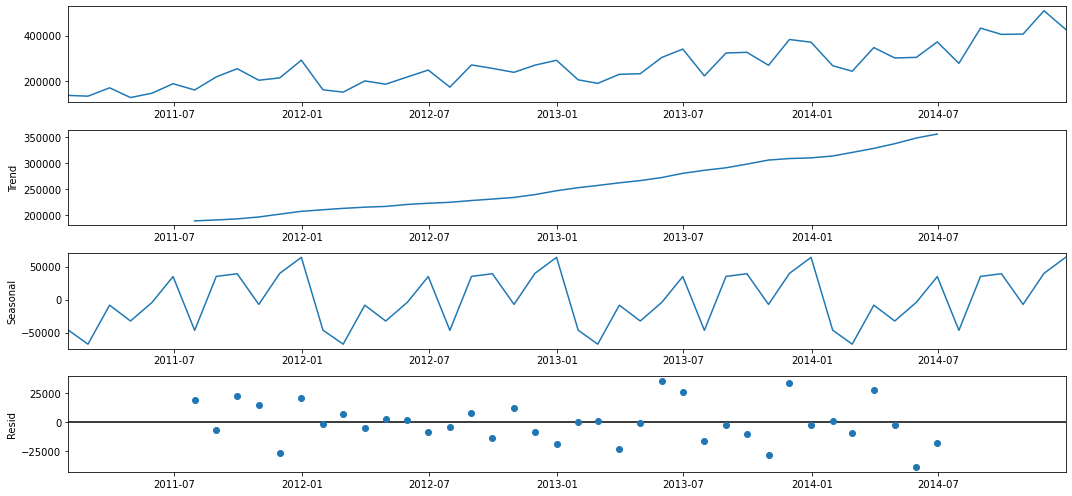

In [5]:
fig(y=7, set_as_global=True)
decomposition = seasonal_decompose(monthly_series)
decomposition.plot()
plt.show()

### 1.2 Weekly

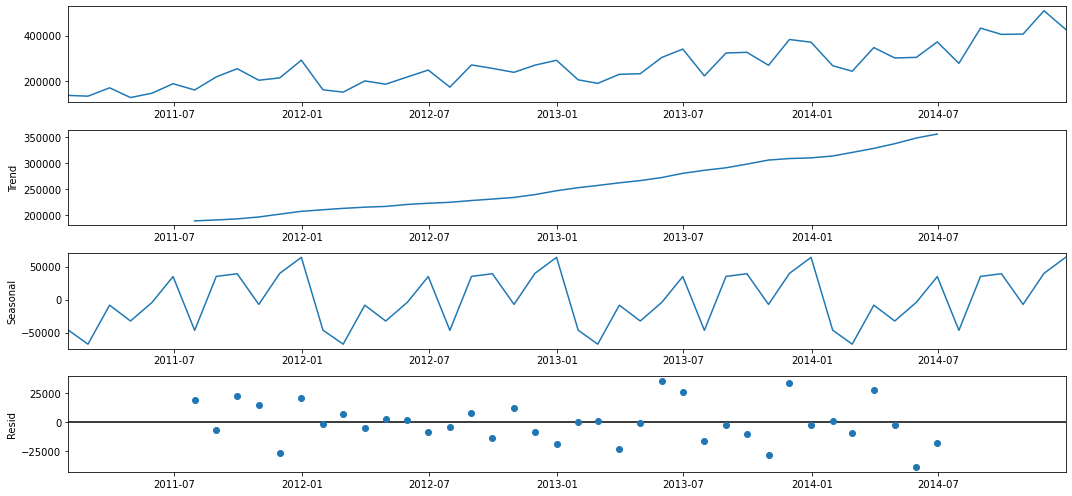

In [6]:
decomposition = seasonal_decompose(monthly_series)
decomposition.plot()
plt.show()

### 1.3 Daily

    Too many Resids

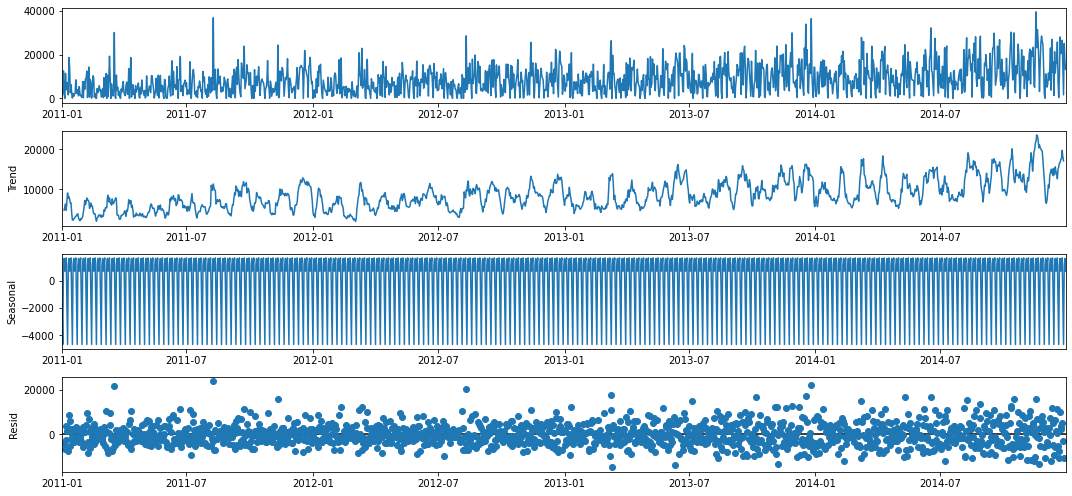

In [7]:
decomposition = seasonal_decompose(daily_series)
decomposition.plot()
plt.show()

## 2.0 Autocorrelation

    Moving Average - q    

### 2.1 Monthly

    We can use a lag of 3 when modeling a monthly time frame.

Autocorrelation with lag equals 1: 73.0%
Autocorrelation with lag equals 2: 68.0%
Autocorrelation with lag equals 3: 77.0%
Autocorrelation with lag equals 4: 54.0%
Autocorrelation with lag equals 5: 55.0%
Autocorrelation with lag equals 6: 66.0%
Autocorrelation with lag equals 7: 47.0%


<Figure size 1080x360 with 0 Axes>

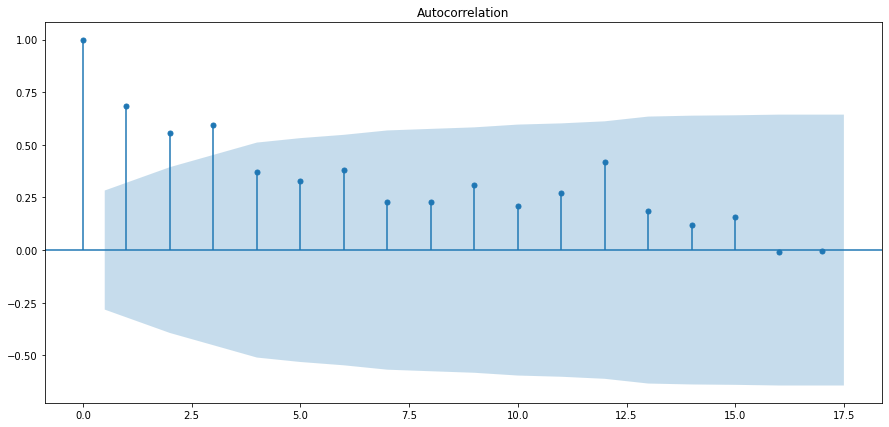

In [8]:
for lag in range(1, 8):
    autocorrelation = monthly_series['sales'].autocorr(lag)
    print(f"Autocorrelation with lag equals {lag}: {np.round(autocorrelation*100)}%" )

fig(15, 5)
plot_acf(monthly_series, alpha = 0.05);

### 2.2 Weekly

Autocorrelation with lag equals 1: 58.0%
Autocorrelation with lag equals 2: 40.0%
Autocorrelation with lag equals 3: 40.0%
Autocorrelation with lag equals 4: 55.0%
Autocorrelation with lag equals 5: 49.0%
Autocorrelation with lag equals 6: 43.0%
Autocorrelation with lag equals 7: 41.0%


<Figure size 1080x360 with 0 Axes>

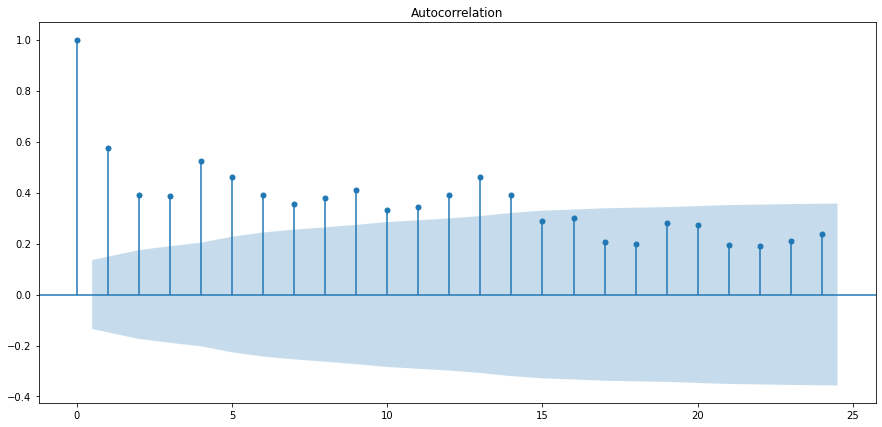

In [9]:
for lag in range(1, 8):
    autocorrelation = weekly_series['sales'].autocorr(lag)
    print(f"Autocorrelation with lag equals {lag}: {np.round(autocorrelation*100)}%" )

fig(15, 5)
plot_acf(weekly_series, alpha = 0.05);

### 2.3 Daily

In [10]:
# for lag in range(1, 8):
#     autocorrelation = daily_series['sales'].autocorr(lag)
#     print(f"Autocorrelation lag equals {lag}: {np.round(autocorrelation*100)}%" )

# fig(15, 5)
# plot_acf(daily_series, alpha = 0.05);

## 3.0 Partial Autocorrelation
    
        AutoRegressive - p

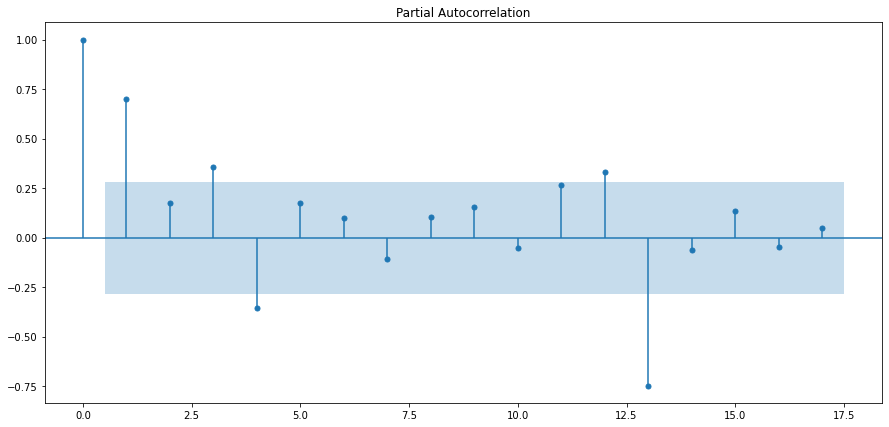

In [11]:
plot_pacf(monthly_series, alpha = 0.05);

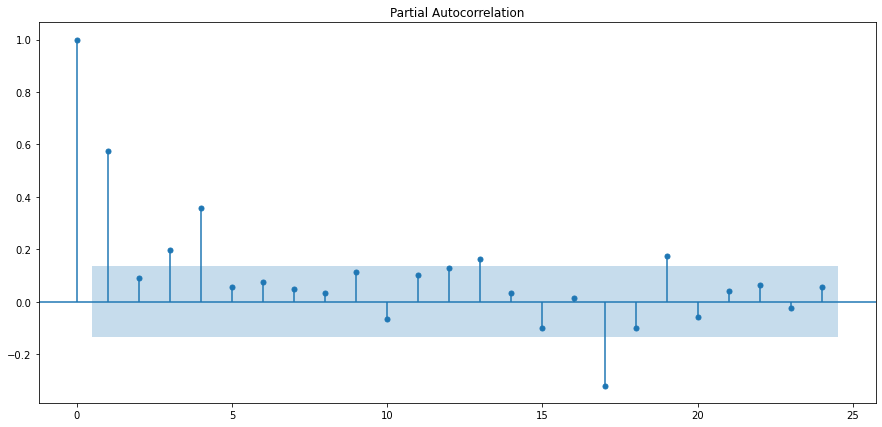

In [12]:
plot_pacf(weekly_series, alpha = 0.05);

## 4.0 Stationarity

**Dickey-Fuller Hypothesis: Series is Not Stationary**

_p-value <= 0.05: Reject the null hypothesis (H0), the data does not have a unit root and is stationary._

### 4.1 Monthly

Integrated = 1

In [13]:
adfuller_test = adfuller(monthly_series['sales'])
print(f'p-value for Dickey-Fuller Test: {round(adfuller_test[1], 3)}')

p-value for Dickey-Fuller Test: 0.962


In [14]:
adfuller_test = adfuller(monthly_series['sales'].diff().dropna())
print(f'p-value for Dickey-Fuller Test: {round(adfuller_test[1], 3)}')

p-value for Dickey-Fuller Test: 0.0


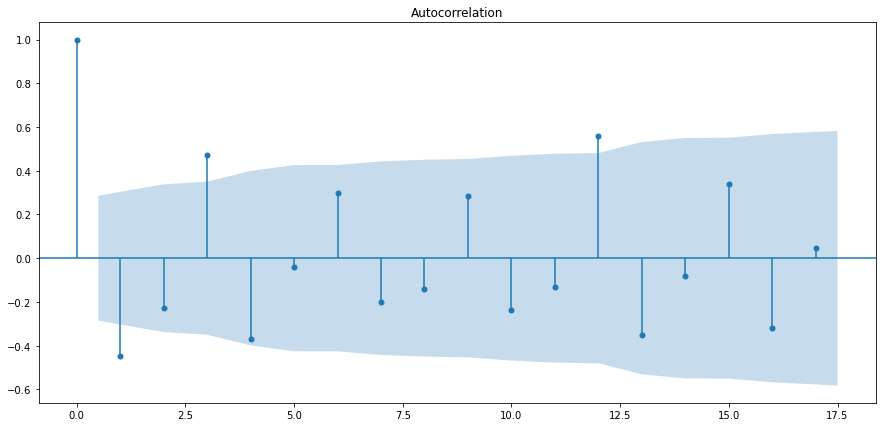

In [15]:
plot_acf(monthly_series['sales'].diff().dropna(), alpha = 0.05);

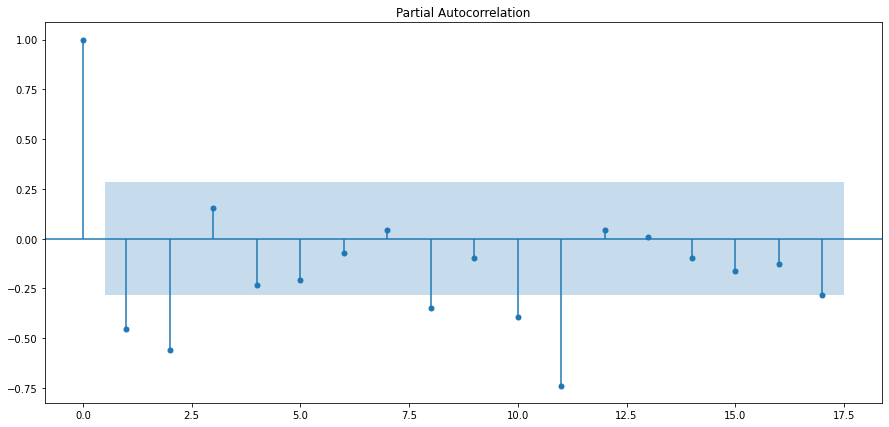

In [16]:
plot_pacf(monthly_series['sales'].diff().dropna(), alpha = 0.05);

### 4.2 Weekly

In [17]:
adfuller_test = adfuller(weekly_series['sales'])
print(f'p-value for Dickey-Fuller Test: {round(adfuller_test[1], 3)}')

p-value for Dickey-Fuller Test: 0.949


In [18]:
adfuller_test = adfuller(weekly_series['sales'].diff().dropna())
print(f'p-value for Dickey-Fuller Test: {round(adfuller_test[1], 3)}')

p-value for Dickey-Fuller Test: 0.0
